# INI-VPINN v1.0.0 (Quick Operator Guide)
## Homogeneous Inverted-T Benchmark

This guide covers only the settings an operator is most likely to change before running the benchmark.

## 1. Recommended workflow

1. Check the main configuration.
2. Show the numbered element grid.
3. Choose `element_types_x` and `element_types_y`.
4. Verify the selected test-function map.
5. Check boundary values and FEM file.
6. Run a short test, then the full training.

For setup, use:

```python
SHOW_SUBDOMAIN_NUMBERS = True
SHOW_TEST_CONFIG = True
SHOW_TEST_FAMILIES = True
```

## 2. Main configuration

```python
N_el_x = 4
N_el_y = 4
N_bound = 80
N_residual = 800
N_quad = 7

N_test_x = N_el_x * [5]
N_test_y = N_el_y * [5]

Net_layer = [2] + [18] * 8 + [1]
N_TRAIN_ITER = 80000 + 1

FEM_FILE = 'V_T_200.txt'
```

Key meanings:

- `N_el_x`, `N_el_y`: number of elements.
- `N_test_x`, `N_test_y`: number of test modes.
- `N_quad`: quadrature order.
- `N_bound`: boundary points per Dirichlet segment.
- `Net_layer`: network architecture.
- `N_TRAIN_ITER`: Adam iterations.
- `FEM_FILE`: FEM reference file.

## 3. Element numbering

The code uses:

```python
number = ey * N_el_x + ex
```

For the default `4 x 4` grid:

```text
12   13   14   15
 8    9   10   11
 4    5    6    7
 0    1    2    3
```

Active elements of the inverted-T are:

```text
12   13   14   15
 8    9   10   11
      5    6
      1    2
```

Elements `0, 3, 4, 7` are outside the physical domain.

## 4. Choosing test functions

Available families:

```python
'jacobi'
'sine'
'cosine'
'trig1to0'
'trig0to1'
```

For the current benchmark, the main families are:

- `jacobi`: zero at both ends; default choice.
- `trig1to0`: nonzero at local `-1`, zero at local `+1`.
- `trig0to1`: zero at local `-1`, nonzero at local `+1`.

Practical rule:

```text
x-direction:
LEFT side   -> trig1to0
RIGHT side  -> trig0to1
otherwise   -> jacobi

y-direction:
BOTTOM side -> trig1to0
TOP side    -> trig0to1
otherwise   -> jacobi
```

Current configuration:

```python
default_type = 'jacobi'

element_types_x = {
    1: 'trig1to0',
    5: 'trig1to0',
    2: 'trig0to1',
    6: 'trig0to1'
}

element_types_y = {
    8: 'trig1to0',
    11: 'trig1to0',
    12: 'trig0to1',
    13: 'trig0to1',
    14: 'trig0to1',
    15: 'trig0to1'
}
```

Edit these two dictionaries rather than editing `test_type_x` and `test_type_y` directly.

Always verify the result with:

```python
SHOW_TEST_CONFIG = True
SHOW_TEST_FAMILIES = True
```

## 5. Boundary conditions

Current Dirichlet data:

```text
bottom stem:  y = -1,  -0.5 <= x <= 0.5,  u = 0
right side:   x = 1,    0 <= y <= 1,       u = 1
left side:    x = -1,   0 <= y <= 1,       u = 0.5
```

If the benchmark geometry or boundary conditions change, review the test-function configuration at the same time.

## 6. Before a full run

Use a short smoke test first, for example:

```python
N_TRAIN_ITER = 100
```

Then restore:

```python
N_TRAIN_ITER = 80000 + 1
```

Final checks:

- element numbering is correct;
- `element_types_x` and `element_types_y` are correct;
- `N_test_x`, `N_test_y`, and `N_quad` are correct;
- boundary values are correct;
- `FEM_FILE` points to the right file.

## Output

The script saves:

```text
INIVPINN_TD.txt
INI_ERROR_VS_WALLTIME.npz
```

and reports FEM error metrics plus training-loss plots.


2026-09-27 11:56:50.193628: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-27 11:56:50.195034: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-27 11:56:50.211346: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-27 11:56:50.211379: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-27 11:56:50.212169: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

Instructions for updating:
non-resource variables are not supported in the long term


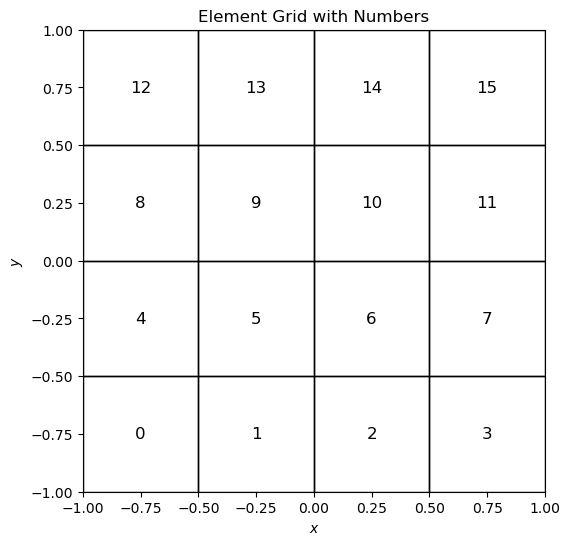

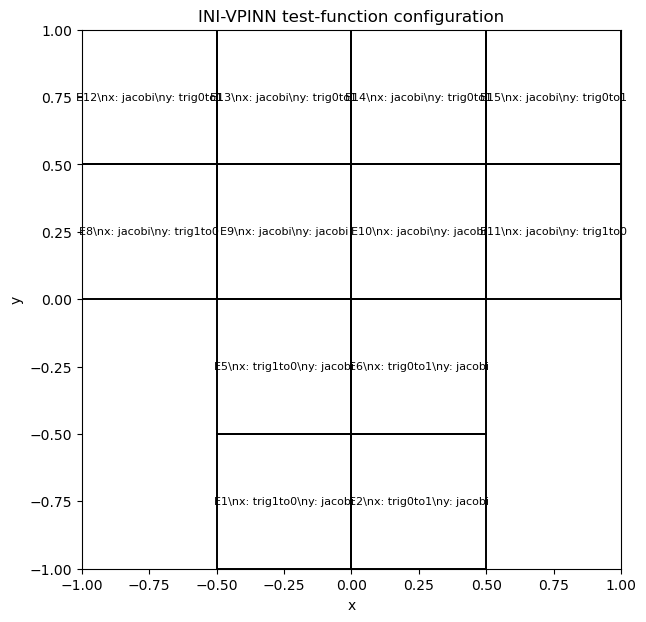

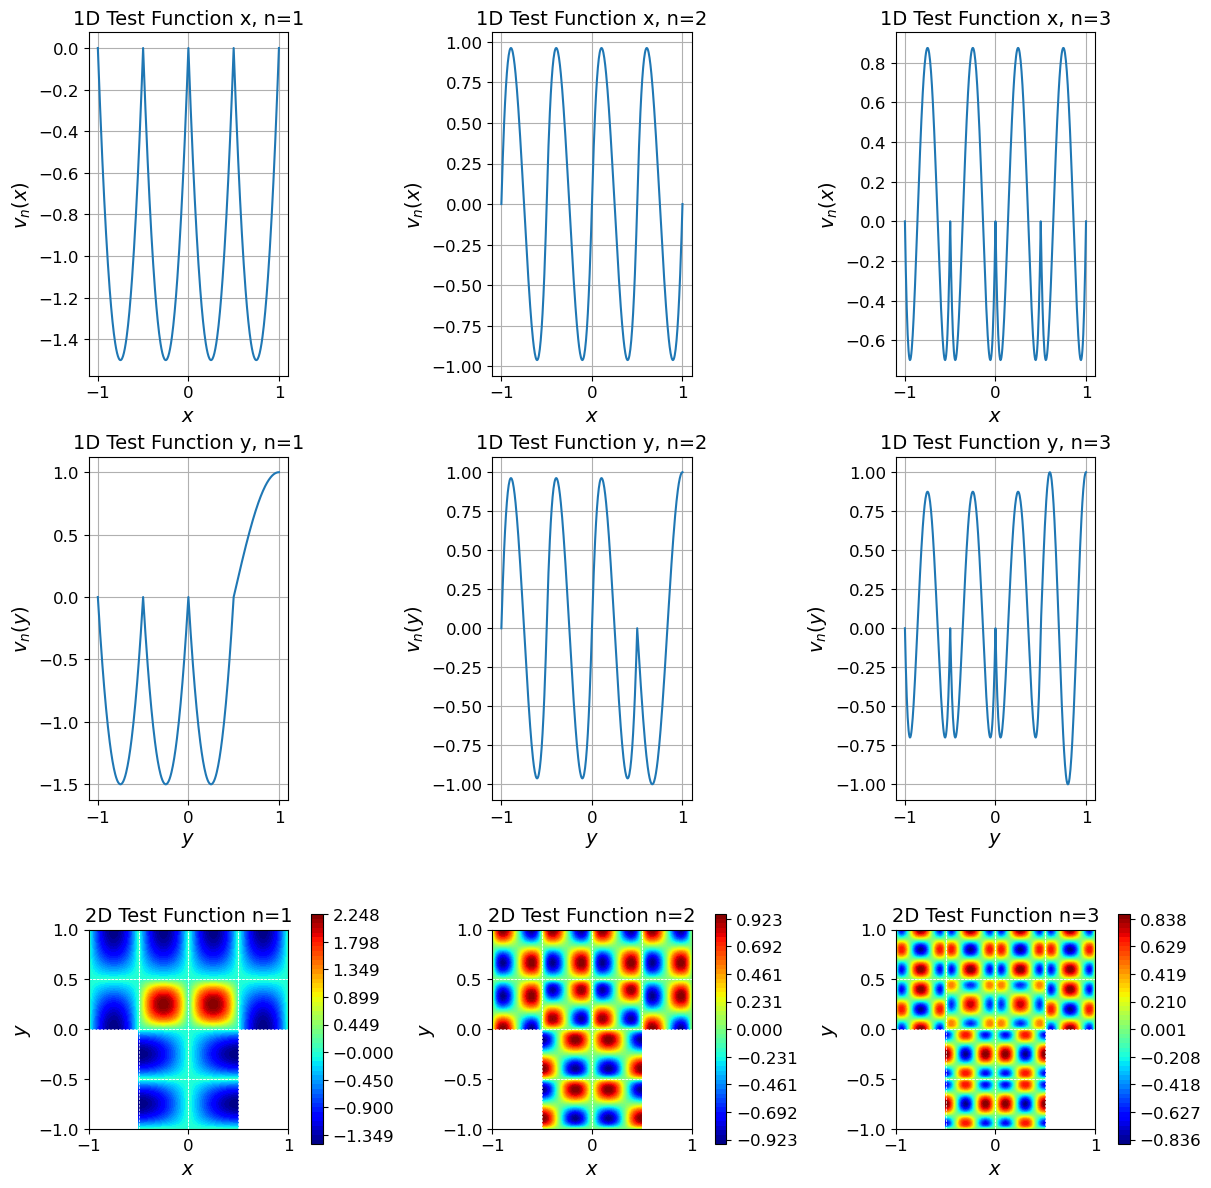

2026-09-27 11:56:55.827707: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-27 11:56:55.827932: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-09-27 11:56:56.065525: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled


  [FEM error] it=0  train_time=0.000 s  relL2=9.760962e-01
It: 0, Total: 3.959e-01, INI(weak): 4.701e-04, BC: 3.950e-01, Best: 3.959e-01 at 0, Block time: 2.32
  [FEM error] it=5000  train_time=27.916 s  relL2=4.771132e-02
It: 5000, Total: 4.596e-04, INI(weak): 2.240e-04, BC: 1.161e-05, Best: 4.596e-04 at 5000, Block time: 25.91
  [FEM error] it=10000  train_time=51.523 s  relL2=2.606578e-02
It: 10000, Total: 1.666e-04, INI(weak): 8.172e-05, BC: 3.195e-06, Best: 1.666e-04 at 10000, Block time: 23.64
  [FEM error] it=15000  train_time=75.121 s  relL2=2.463294e-02
It: 15000, Total: 1.793e-04, INI(weak): 8.645e-05, BC: 6.377e-06, Best: 1.666e-04 at 10000, Block time: 23.39
  [FEM error] it=20000  train_time=98.473 s  relL2=1.969081e-02
It: 20000, Total: 1.092e-04, INI(weak): 5.193e-05, BC: 5.315e-06, Best: 1.092e-04 at 20000, Block time: 23.58
  [FEM error] it=25000  train_time=122.134 s  relL2=1.197887e-02
It: 25000, Total: 4.144e-05, INI(weak): 1.865e-05, BC: 4.148e-06, Best: 4.144e-05 

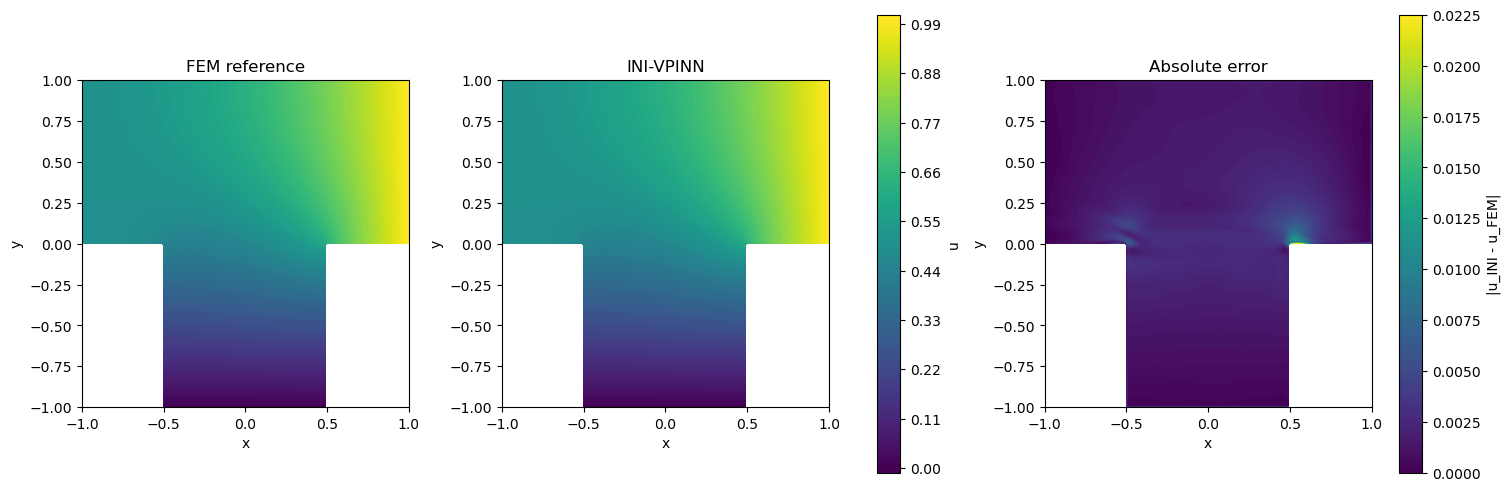

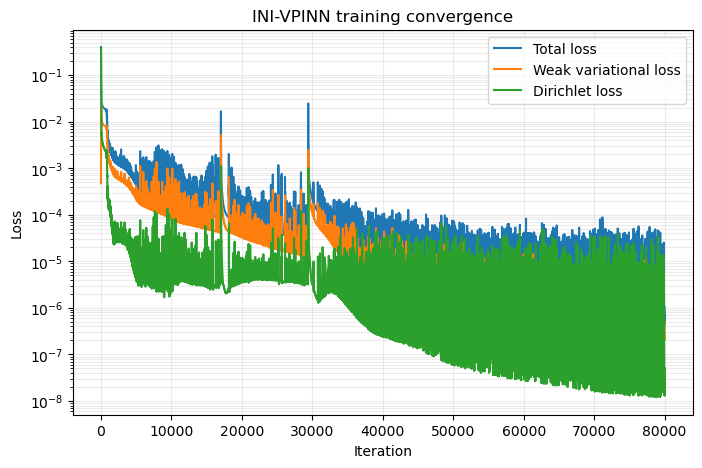


Saved prediction : INIVPINN_TD.txt
Saved history    : INI_ERROR_VS_WALLTIME.npz
INI-VPINN simulation completed.


In [1]:
"""
INI-VPINN v1.0.0 — Homogeneous inverted-T benchmark

This script is organized as an operator-facing workflow:
  1) imports and numerical utilities
  2) weighting/test functions
  3) VPINN model
  4) configuration
  5) geometry and boundary data
  6) quadrature and weak-form RHS
  7) test-function configuration visualization
  8) FEM reference loading
  9) training
 10) prediction, FEM error metrics, loss curves, and final plots

The operator can inspect the test-function map before training and can load
the FEM reference file through load_fem_reference().

This is the ALL-IN-ONE release: quadrature, test functions, model, training,
visualization, FEM loading, prediction, error analysis, and loss plots are
contained in this single Python file.
"""

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
import numpy as np
import matplotlib.pyplot as plt
from pyDOE2 import lhs
from scipy.special import eval_jacobi, roots_jacobi, beta as beta_function
from math import comb

def Jacobi(n, alpha, beta, x):
    x = np.asarray(x, dtype=float)
    if n < 0:
        return np.zeros_like(x)
    return eval_jacobi(int(n), alpha, beta, x)

def DJacobi(n, alpha, beta, x, k=1):
    x = np.asarray(x, dtype=float)
    n = int(n)
    k = int(k)
    if k < 0:
        raise ValueError("Derivative order k must be non-negative.")
    if k == 0:
        return Jacobi(n, alpha, beta, x)
    if n < k:
        return np.zeros_like(x)
    factor = 1.0
    for j in range(k):
        factor *= 0.5 * (n + alpha + beta + 1.0 + j)
    return factor * eval_jacobi(
        n - k, alpha + k, beta + k, x
    )

def GaussLobattoJacobiWeights(Q, alpha=0.0, beta=0.0):
    Q = int(Q)
    if Q < 2:
        raise ValueError("Gauss-Lobatto-Jacobi quadrature requires Q >= 2.")
    # The VPINN scripts use alpha=beta=0 (Legendre weight).
    # Keep a general Jacobi implementation for completeness.
    if Q == 2:
        x = np.array([-1.0, 1.0], dtype=float)
    else:
        interior, _ = roots_jacobi(Q - 2, alpha + 1.0, beta + 1.0)
        x = np.concatenate(([-1.0], interior, [1.0]))
    # Compute interpolatory weights by matching the first Q weighted moments.
    # This is stable for the small quadrature orders used in these scripts.
    moments = np.empty(Q, dtype=float)
    for k in range(Q):
        # Integral_{-1}^1 x^k (1-x)^alpha (1+x)^beta dx
        # after t=(x+1)/2 and binomial expansion of (2t-1)^k.
        val = 0.0
        for j in range(k + 1):
            val += (
                comb(k, j)
                * (2.0 ** j)
                * ((-1.0) ** (k - j))
                * beta_function(beta + j + 1.0, alpha + 1.0)
            )
        moments[k] = (2.0 ** (alpha + beta + 1.0)) * val
    vandermonde = np.vstack([x ** k for k in range(Q)])
    w = np.linalg.solve(vandermonde, moments)
    return x, w

import time
from scipy.interpolate import griddata
import os
np.random.seed(1234)
tf.set_random_seed(1234)

# ============================================================================
# TEST FUNCTIONS
# ============================================================================

def get_test_fcn(typ, N_test, pts):
    if typ == 'jacobi':
        test_total = []
        for n in range(1, N_test + 1):
            test = Jacobi(n + 1, 0, 0, pts) - Jacobi(n - 1, 0, 0, pts)
            test_total.append(test)
        return np.asarray(test_total)
    elif typ == 'sine':
        test_total = []
        for n in range(1, N_test + 1):
            test = np.sin(n * np.pi * (pts + 1) / 2)
            test_total.append(test)
        return np.asarray(test_total)
    elif typ == 'cosine':
        test_total = []
        for n in range(0, N_test):
            test = np.cos(n * np.pi * (pts + 1) / 2)
            test_total.append(test)
        return np.asarray(test_total)
    elif typ == 'trig1to0':
        test_total = []
        for n in range(N_test):
            k = 2 * n + 1
            arg = k * np.pi / 2 * (pts + 1) / 2
            test = np.cos(arg)
            test_total.append(test)
        return np.asarray(test_total)
    elif typ == 'trig0to1':
        test_total = []
        for n in range(N_test):
            k = 2 * n + 1
            arg = k * np.pi / 2 * (pts + 1) / 2
            sign = (-1) ** n
            test = sign * np.sin(arg)
            test_total.append(test)
        return np.asarray(test_total)

def get_dtest_fcn(typ, N_test, pts):
    if typ == 'jacobi':
        d1test_total = []
        d2test_total = []
        for n in range(1, N_test + 1):
            if n == 1:
                d1test = ((n + 2) / 2) * Jacobi(n, 1, 1, pts)
                d2test = ((n + 2) * (n + 3) / (2 * 2)) * Jacobi(n - 1, 2, 2, pts)
                d1test_total.append(d1test)
                d2test_total.append(d2test)
            elif n == 2:
                d1test = ((n + 2) / 2) * Jacobi(n, 1, 1, pts) - ((n) / 2) * Jacobi(n - 2, 1, 1, pts)
                d2test = ((n + 2) * (n + 3) / (2 * 2)) * Jacobi(n - 1, 2, 2, pts)
                d1test_total.append(d1test)
                d2test_total.append(d2test)
            else:
                d1test = ((n + 2) / 2) * Jacobi(n, 1, 1, pts) - ((n) / 2) * Jacobi(n - 2, 1, 1, pts)
                d2test = ((n + 2) * (n + 3) / (2 * 2)) * Jacobi(n - 1, 2, 2, pts) - ((n) * (n + 1) / (2 * 2)) * Jacobi(n - 3, 2, 2, pts)
                d1test_total.append(d1test)
                d2test_total.append(d2test)
        return np.asarray(d1test_total), np.asarray(d2test_total)
    elif typ == 'sine':
        d1test_total = []
        d2test_total = []
        for n in range(1, N_test + 1):
            arg = n * np.pi * (pts + 1) / 2
            d1test = (n * np.pi / 2) * np.cos(arg)
            d2test = - (n * np.pi / 2)**2 * np.sin(arg)
            d1test_total.append(d1test)
            d2test_total.append(d2test)
        return np.asarray(d1test_total), np.asarray(d2test_total)
    elif typ == 'cosine':
        d1test_total = []
        d2test_total = []
        for n in range(0, N_test):
            arg = n * np.pi * (pts + 1) / 2
            d1test = - (n * np.pi / 2) * np.sin(arg)
            d2test = - (n * np.pi / 2)**2 * np.cos(arg)
            d1test_total.append(d1test)
            d2test_total.append(d2test)
        return np.asarray(d1test_total), np.asarray(d2test_total)
    elif typ == 'trig1to0':
        d1test_total = []
        d2test_total = []
        for n in range(N_test):
            k = 2 * n + 1
            scale = k * np.pi / 4
            arg = k * np.pi / 2 * (pts + 1) / 2
            d1test = - scale * np.sin(arg)
            d2test = - scale**2 * np.cos(arg)
            d1test_total.append(d1test)
            d2test_total.append(d2test)
        return np.asarray(d1test_total), np.asarray(d2test_total)
    elif typ == 'trig0to1':
        d1test_total = []
        d2test_total = []
        for n in range(N_test):
            k = 2 * n + 1
            scale = k * np.pi / 4
            arg = k * np.pi / 2 * (pts + 1) / 2
            sign = (-1) ** n
            d1test = sign * scale * np.cos(arg)
            d2test = sign * - scale**2 * np.sin(arg)
            d1test_total.append(d1test)
            d2test_total.append(d2test)
        return np.asarray(d1test_total), np.asarray(d2test_total)

# ============================================================================
# Define the VPINN class, which implements a Variational Physics-Informed Neural Network
# for solving the 2D Poisson equation. This class handles network initialization,
# loss computation, training, and prediction.
# ============================================================================
# -----------------------------------------------------------------------------
#   Delta u = f in Omega
#   u = g_D on Gamma_D
#   d_n u = g_N on Gamma_N
#
# For the inverted-T benchmark in this script:
#   Gamma_D: left outer edge (g_D=0.5), right outer edge (g_D=1),
#            and bottom of the stem (g_D=0).
#   Gamma_N: all remaining physical boundary segments, with g_N=0.
#
#   + int_K u Delta(v)
#   - int_{partial K cap interior} u d_n(v)
#   - int_{partial K cap Gamma_D} g_D d_n(v)
#   + int_{partial K cap Gamma_N} g_N v
#   - int_K f v.
#
# The interior-edge term is essential for element-local test functions.
# -----------------------------------------------------------------------------
# ============================================================================
# OPERATOR VISUALIZATION
# ============================================================================

def plot_subdomain_numbering(grid_x, grid_y):
    """Original element-grid numbering plot used as the operator guide."""
    fig, ax = plt.subplots(figsize=(6, 6))

    for ex in range(N_el_x):
        for ey in range(N_el_y):
            rect = plt.Rectangle(
                (grid_x[ex], grid_y[ey]),
                delta_x,
                delta_y,
                fill=None,
                edgecolor="black",
            )
            ax.add_patch(rect)

            # Original row-major numbering:
            # ey runs from bottom to top, ex from left to right.
            number = ey * N_el_x + ex
            center_x = grid_x[ex] + delta_x / 2
            center_y = grid_y[ey] + delta_y / 2

            ax.text(
                center_x,
                center_y,
                str(number),
                ha="center",
                va="center",
                fontsize=12,
            )

    ax.set_xlim([x_l, x_r])
    ax.set_ylim([y_l, y_u])
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_title("Element Grid with Numbers")
    plt.show()

def plot_test_function_configuration(grid_x, grid_y, test_type_x, test_type_y):
    """Show the test-function family selected in every active T element."""
    n_el_x = len(grid_x) - 1
    n_el_y = len(grid_y) - 1
    fig, ax = plt.subplots(figsize=(8, 7))

    for ex in range(n_el_x):
        for ey in range(n_el_y):
            if ey < n_el_y // 2 and (ex < 1 or ex > 2):
                continue

            x0, x1 = grid_x[ex], grid_x[ex + 1]
            y0, y1 = grid_y[ey], grid_y[ey + 1]
            element_id = ey * n_el_x + ex

            ax.add_patch(
                plt.Rectangle(
                    (x0, y0), x1 - x0, y1 - y0,
                    fill=False, edgecolor="black", linewidth=1.4
                )
            )
            ax.text(
                0.5 * (x0 + x1), 0.5 * (y0 + y1),
                "E{}\\nx: {}\\ny: {}".format(
                    element_id, test_type_x[ex][ey], test_type_y[ex][ey]
                ),
                ha="center", va="center", fontsize=8
            )

    ax.set_xlim(grid_x[0], grid_x[-1])
    ax.set_ylim(grid_y[0], grid_y[-1])
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("INI-VPINN test-function configuration")
    plt.show()

def plot_representative_test_functions(N_test=3):
    """
    Original-style pre-training test-function figure.

    Row 1: first three 1-D test functions in x.
    Row 2: first three 1-D test functions in y.
    Row 3: corresponding 2-D tensor-product test functions on the T-domain.
    """
    fontsize = 14
    labelsize = 12
    n_plot = min(3, int(N_test))

    fig, axes = plt.subplots(
        3, 3, figsize=(12, 12), constrained_layout=True
    )

    ref = np.linspace(-1.0, 1.0, 100)[:, None]

    # ------------------------------------------------------------------
    # Row 1: x-direction test functions.
    # Use ey=2, which is an active row across all four x-elements.
    # ------------------------------------------------------------------
    representative_ey = min(2, N_el_y - 1)

    for n in range(n_plot):
        ax = axes[0, n]
        x_all = []
        v_all = []

        for ex in range(N_el_x):
            x_phys = (
                grid_x[ex]
                + 0.5 * (grid_x[ex + 1] - grid_x[ex]) * (ref + 1.0)
            )

            family = test_type_x[ex][representative_ey]
            values = get_test_fcn(family, N_test_x[ex], ref)

            x_all.append(x_phys[:, 0])
            v_all.append(values[n].reshape(-1))

        ax.plot(np.concatenate(x_all), np.concatenate(v_all))
        ax.set_xlabel(r"$x$", fontsize=fontsize)
        ax.set_ylabel(r"$v_n(x)$", fontsize=fontsize)
        ax.set_title(
            "1D Test Function x, n={}".format(n + 1),
            fontsize=fontsize,
        )
        ax.grid(True)
        ax.tick_params(labelsize=labelsize)

    # ------------------------------------------------------------------
    # Row 2: y-direction test functions.
    # Use ex=1, which is active through the complete vertical stem/top.
    # ------------------------------------------------------------------
    representative_ex = min(1, N_el_x - 1)

    for n in range(n_plot):
        ax = axes[1, n]
        y_all = []
        v_all = []

        for ey in range(N_el_y):
            y_phys = (
                grid_y[ey]
                + 0.5 * (grid_y[ey + 1] - grid_y[ey]) * (ref + 1.0)
            )

            family = test_type_y[representative_ex][ey]
            values = get_test_fcn(family, N_test_y[ey], ref)

            y_all.append(y_phys[:, 0])
            v_all.append(values[n].reshape(-1))

        ax.plot(np.concatenate(y_all), np.concatenate(v_all))
        ax.set_xlabel(r"$y$", fontsize=fontsize)
        ax.set_ylabel(r"$v_n(y)$", fontsize=fontsize)
        ax.set_title(
            "1D Test Function y, n={}".format(n + 1),
            fontsize=fontsize,
        )
        ax.grid(True)
        ax.tick_params(labelsize=labelsize)

    # Hide unused columns if fewer than three modes are requested.
    for n in range(n_plot, 3):
        axes[0, n].axis("off")
        axes[1, n].axis("off")
        axes[2, n].axis("off")

    # ------------------------------------------------------------------
    # Row 3: 2-D tensor-product test functions on ACTIVE T elements only.
    # ------------------------------------------------------------------
    local_ref = np.linspace(-1.0, 1.0, 50)[:, None]

    for n in range(n_plot):
        ax = axes[2, n]

        local_fields = []
        vmin = np.inf
        vmax = -np.inf

        for ex in range(N_el_x):
            for ey in range(N_el_y):
                # Skip the four cells outside the inverted-T domain.
                if ey < N_el_y // 2 and (ex < 1 or ex > 2):
                    continue

                vx = get_test_fcn(
                    test_type_x[ex][ey], N_test_x[ex], local_ref
                )[n].reshape(-1)

                vy = get_test_fcn(
                    test_type_y[ex][ey], N_test_y[ey], local_ref
                )[n].reshape(-1)

                field = np.outer(vy, vx)

                x_phys = (
                    grid_x[ex]
                    + 0.5 * (grid_x[ex + 1] - grid_x[ex])
                    * (local_ref[:, 0] + 1.0)
                )
                y_phys = (
                    grid_y[ey]
                    + 0.5 * (grid_y[ey + 1] - grid_y[ey])
                    * (local_ref[:, 0] + 1.0)
                )

                Xp, Yp = np.meshgrid(x_phys, y_phys)
                local_fields.append((Xp, Yp, field))

                vmin = min(vmin, np.min(field))
                vmax = max(vmax, np.max(field))

        if np.isclose(vmin, vmax):
            levels = 20
        else:
            levels = np.linspace(vmin, vmax, 51)

        contour = None
        for Xp, Yp, field in local_fields:
            contour = ax.contourf(
                Xp, Yp, field, levels=levels, cmap="jet"
            )

        if contour is not None:
            cbar = fig.colorbar(contour, ax=ax, shrink=0.67)
            cbar.ax.tick_params(labelsize=labelsize)

        # Draw only the element-grid segments belonging to the T-domain.
        for ex in range(N_el_x):
            for ey in range(N_el_y):
                if ey < N_el_y // 2 and (ex < 1 or ex > 2):
                    continue

                x0, x1 = grid_x[ex], grid_x[ex + 1]
                y0, y1 = grid_y[ey], grid_y[ey + 1]

                ax.plot([x0, x1], [y0, y0], "w--", linewidth=0.5)
                ax.plot([x0, x1], [y1, y1], "w--", linewidth=0.5)
                ax.plot([x0, x0], [y0, y1], "w--", linewidth=0.5)
                ax.plot([x1, x1], [y0, y1], "w--", linewidth=0.5)

        ax.set_xlim(x_l, x_r)
        ax.set_ylim(y_l, y_u)
        ax.set_aspect("equal")
        ax.set_xlabel(r"$x$", fontsize=fontsize)
        ax.set_ylabel(r"$y$", fontsize=fontsize)
        ax.set_title(
            "2D Test Function n={}".format(n + 1),
            fontsize=fontsize,
        )
        ax.tick_params(labelsize=labelsize)

    plt.show()

def plot_loss_history(total_loss, weak_loss, boundary_loss):
    """Plot total, variational, and Dirichlet loss histories."""
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.semilogy(total_loss, label="Total loss")
    ax.semilogy(weak_loss, label="Weak variational loss")
    ax.semilogy(boundary_loss, label="Dirichlet loss")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.set_title("INI-VPINN training convergence")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend()
    plt.show()

class VPINN:
    def __init__(self, X_u_train, u_train, X_f_train, f_train, X_quad, W_quad, U_exact_total, F_exact_total, gridx, gridy, N_testfcn, X_test, u_test, layers, test_type_x, test_type_y):
        self.x = X_u_train[:,0:1]
        self.y = X_u_train[:,1:2]
        self.utrain = u_train
        self.xquad = X_quad[:,0:1]
        self.yquad = X_quad[:,1:2]
        self.wquad = W_quad
        self.xf = X_f_train[:,0:1]
        self.yf = X_f_train[:,1:2]
        self.ftrain = f_train
        self.xtest = X_test[:,0:1]
        self.ytest = X_test[:,1:2]
        self.utest = u_test
        self.Nelementx = np.size(N_testfcn[0])
        self.Nelementy = np.size(N_testfcn[1])
        self.Ntestx = N_testfcn[0][0]
        self.Ntesty = N_testfcn[1][0]
        self.U_ext_total = U_exact_total
        self.F_ext_total = F_exact_total
        self.test_type_x = test_type_x
        self.test_type_y = test_type_y
        self.layers = layers
        self.weights, self.biases, self.a = self.initialize_NN(layers)
        self.x_tf = tf.placeholder(tf.float64, shape=[None, self.x.shape[1]])
        self.y_tf = tf.placeholder(tf.float64, shape=[None, self.y.shape[1]])
        self.u_tf = tf.placeholder(tf.float64, shape=[None, self.utrain.shape[1]])
        self.x_f_tf = tf.placeholder(tf.float64, shape=[None, self.xf.shape[1]])
        self.y_f_tf = tf.placeholder(tf.float64, shape=[None, self.yf.shape[1]])
        self.f_tf = tf.placeholder(tf.float64, shape=[None, self.ftrain.shape[1]])
        self.x_test = tf.placeholder(tf.float64, shape=[None, self.xtest.shape[1]])
        self.y_test = tf.placeholder(tf.float64, shape=[None, self.ytest.shape[1]])
        self.u_pred_boundary = self.net_u(self.x_tf, self.y_tf)
        self.f_pred = self.net_f(self.x_f_tf, self.y_f_tf)
        self.u_test = self.net_u(self.x_test, self.y_test)
        self.iniloss_total = 0.0
        def active_element(ix, iy):
            if ix < 0 or ix >= self.Nelementx or iy < 0 or iy >= self.Nelementy:
                return False
            return not (iy < self.Nelementy // 2 and (ix < 1 or ix > 2))
        for ex in range(self.Nelementx):
            for ey in range(self.Nelementy):
                if not active_element(ex, ey):
                    continue
                F_ext_element = self.F_ext_total[ex, ey]
                Ntest_elementx = N_testfcn[0][ex]
                Ntest_elementy = N_testfcn[1][ey]
                test_type_x_elem = self.test_type_x[ex][ey]
                test_type_y_elem = self.test_type_y[ex][ey]
                Jx = (gridx[ex+1] - gridx[ex]) / 2.0
                Jy = (gridy[ey+1] - gridy[ey]) / 2.0
                J = Jx * Jy
                x_quad_element = tf.constant(gridx[ex] + Jx * (self.xquad + 1.0), dtype=tf.float64)
                y_quad_element = tf.constant(gridy[ey] + Jy * (self.yquad + 1.0), dtype=tf.float64)
                u_quad = self.net_u(x_quad_element, y_quad_element)
                vx = get_test_fcn(test_type_x_elem, Ntest_elementx, self.xquad)
                dvx, _ = get_dtest_fcn(test_type_x_elem, Ntest_elementx, self.xquad)
                vy = get_test_fcn(test_type_y_elem, Ntest_elementy, self.yquad)
                dvy, _ = get_dtest_fcn(test_type_y_elem, Ntest_elementy, self.yquad)
                du_dx = tf.gradients(u_quad, x_quad_element)[0]
                du_dy = tf.gradients(u_quad, y_quad_element)[0]
                ini_x = tf.convert_to_tensor([[J * tf.reduce_sum(self.wquad[:,0:1] * self.wquad[:,1:2] * (dvx[r] / Jx) * vy[k] * du_dx) for r in range(Ntest_elementx)] for k in range(Ntest_elementy)], dtype=tf.float64)
                ini_y = tf.convert_to_tensor([[J * tf.reduce_sum(self.wquad[:,0:1] * self.wquad[:,1:2] * vx[r] * (dvy[k] / Jy) * du_dy) for r in range(Ntest_elementx)] for k in range(Ntest_elementy)], dtype=tf.float64)
                INI_NN_element = -ini_x - ini_y
                Res_INI_element = tf.reshape(INI_NN_element - F_ext_element, [1, -1])
                self.iniloss_total += tf.reduce_mean(tf.square(Res_INI_element))
        self.lossb = tf.reduce_mean(tf.square(self.u_tf - self.u_pred_boundary))
        self.loss_ini_weak = self.iniloss_total
        self.loss = self.lossb + 2.0 * self.loss_ini_weak
        self.optimizer_Adam = tf.train.AdamOptimizer(1e-3)
        self.train_op_Adam = self.optimizer_Adam.minimize(self.loss)
        self.saver = tf.train.Saver(max_to_keep=1)
        config = tf.ConfigProto(allow_soft_placement=True, intra_op_parallelism_threads=0, inter_op_parallelism_threads=0)
        self.sess = tf.Session(config=config)
        self.init = tf.global_variables_initializer()
        self.sess.run(self.init)
        self.best_loss = np.inf
        self.best_iteration = -1
    def initialize_NN(self, layers):
        weights = []
        biases = []
        num_layers = len(layers)
        for l in range(0, num_layers-1):
            W = self.xavier_init(size=[layers[l], layers[l+1]])
            b = tf.Variable(tf.zeros([1,layers[l+1]], dtype=tf.float64), dtype=tf.float64)
            a = tf.Variable(0.01, dtype=tf.float64)
            weights.append(W)
            biases.append(b)
        return weights, biases, a
    # Xavier initialization for weights
    def xavier_init(self, size):
        in_dim = size[0]
        out_dim = size[1]
        xavier_stddev = np.sqrt(2/(in_dim + out_dim), dtype=np.float64)
        return tf.Variable(tf.truncated_normal([in_dim, out_dim], stddev=xavier_stddev, dtype=tf.float64), dtype=tf.float64)
    # Forward pass through the neural network (fully connected with tanh activations)
    def neural_net(self, X, weights, biases, a):
        num_layers = len(weights) + 1
        H = X
        for l in range(0, num_layers-2):
            W = weights[l]
            b = biases[l]
            H = tf.tanh(tf.add(tf.matmul(H, W), b))
        W = weights[-1]
        b = biases[-1]
        Y = tf.add(tf.matmul(H, W), b)
        return Y
    # Predict u(x,y) using the neural network
    def net_u(self, x, y):
        u = self.neural_net(tf.concat([x,y],1), self.weights, self.biases, self.a)
        return u
    # Compute first and second derivatives of u w\.r.t. x
    def net_dxu(self, x, y):
        u = self.net_u(x, y)
        d1xu = tf.gradients(u, x)[0]
        d2xu = tf.gradients(d1xu, x)[0]
        return d1xu, d2xu
    # Compute first and second derivatives of u w\.r.t. y
    def net_dyu(self, x, y):
        u = self.net_u(x, y)
        d1yu = tf.gradients(u, y)[0]
        d2yu = tf.gradients(d1yu, y)[0]
        return d1yu, d2yu
    # Compute the PDE residual f = Laplacian(u)
    def net_f(self, x, y):
        u = self.net_u(x, y)
        d1xu = tf.gradients(u, x)[0]
        d2xu = tf.gradients(d1xu, x)[0]
        d1yu = tf.gradients(u, y)[0]
        d2yu = tf.gradients(d1yu, y)[0]
        ftemp = (d2xu + d2yu)  # Original INI convention: Delta(u) = f
        return ftemp
    # ============================================================================
    # Training method:
    # - Runs Adam for nIter iterations
    # - Restores the lowest-loss model automatically at the end
    def train(self, nIter, diagnostic_every=10, error_every=5000, u_fem_eval=None, history_file=None):
        base_dict = {self.x_tf:self.x, self.y_tf:self.y, self.u_tf:self.utrain, self.x_test:self.xtest, self.y_test:self.ytest, self.x_f_tf:self.xf, self.y_f_tf:self.yf}
        checkpoint_dir = "checkpoints_ini"
        os.makedirs(checkpoint_dir, exist_ok=True)
        best_model_path = os.path.join(checkpoint_dir, "best_ini_model.ckpt")
        best_loss = np.inf
        best_iteration = -1
        check_every = 5000
        train_clock_start = time.time()
        diagnostic_overhead = 0.0
        print_clock = time.time()
        self.wall_time_his = []
        self.rel_l2_his = []
        self.error_iter_his = []
        def current_training_time():
            return time.time() - train_clock_start - diagnostic_overhead
        def record_fem_error(iteration):
            nonlocal diagnostic_overhead
            if u_fem_eval is None:
                return
            diag_start = time.time()
            pred = self.predict().reshape(-1)
            ref = np.asarray(u_fem_eval, dtype=float).reshape(-1)
            valid = np.isfinite(ref) & np.isfinite(pred)
            if not np.any(valid):
                raise RuntimeError("No valid FEM/test-grid points for relative L2 error.")
            denom = np.linalg.norm(ref[valid])
            if denom <= 0.0:
                raise RuntimeError("FEM reference norm is zero.")
            rel_l2 = np.linalg.norm(pred[valid] - ref[valid]) / denom
            diagnostic_overhead += time.time() - diag_start
            t_train = current_training_time()
            self.error_iter_his.append(int(iteration))
            self.wall_time_his.append(float(t_train))
            self.rel_l2_his.append(float(rel_l2))
            print("  [FEM error] it=%d  train_time=%.3f s  relL2=%.6e" % (iteration, t_train, rel_l2))
            if history_file is not None:
                np.savez(history_file, times=np.asarray(self.wall_time_his,dtype=float), errors=np.asarray(self.rel_l2_his,dtype=float), iterations=np.asarray(self.error_iter_his,dtype=int), n_quad=np.asarray(self.n_quad_used if hasattr(self,"n_quad_used") else -1))
        record_fem_error(0)
        last_diag = (np.nan, np.nan)
        for it in range(nIter):
            need_diag = (it % max(1,int(diagnostic_every)) == 0 or it == nIter-1)
            if need_diag:
                _, loss_value, loss_ini_weak, loss_b = self.sess.run([self.train_op_Adam, self.loss, self.loss_ini_weak, self.lossb], base_dict)
                last_diag = (float(loss_ini_weak), float(loss_b))
            else:
                _, loss_value = self.sess.run([self.train_op_Adam, self.loss], base_dict)
                loss_ini_weak, loss_b = last_diag
            loss_value = float(loss_value)
            loss_his.append(loss_value)
            loss_ini_weak_his.append(float(loss_ini_weak))
            loss_bc_his.append(float(loss_b))
            if it % check_every == 0 and np.isfinite(loss_value) and loss_value < best_loss:
                best_loss = loss_value
                best_iteration = it
                self.saver.save(self.sess, best_model_path)
            completed = it + 1
            if u_fem_eval is not None and (completed % max(1,int(error_every)) == 0 or completed == nIter):
                record_fem_error(completed)
            if it % 5000 == 0:
                elapsed_block = time.time() - print_clock
                print_clock = time.time()
                print("It: %d, Total: %.3e, INI(weak): %.3e, BC: %.3e, Best: %.3e at %d, Block time: %.2f" % (it, loss_value, loss_ini_weak, loss_b, best_loss, best_iteration, elapsed_block))
        final_loss = float(self.sess.run(self.loss, base_dict))
        if np.isfinite(final_loss) and final_loss < best_loss:
            best_loss = final_loss
            best_iteration = nIter - 1
            self.saver.save(self.sess, best_model_path)
        if best_iteration < 0:
            raise RuntimeError("No finite loss was obtained.")
        self.saver.restore(self.sess, best_model_path)
        self.best_loss = best_loss
        self.best_iteration = best_iteration
        print("\nINI training finished.")
        print("Best iteration   : %d" % self.best_iteration)
        print("Best total loss  : %.6e" % self.best_loss)
        print("Best checkpoint  : %s" % best_model_path)
    # Prediction method: Evaluate the network at test points
    def predict(self):
        u_pred = self.sess.run(self.u_test, {self.x_test: self.xtest, self.y_test: self.ytest})
        return u_pred

# ============================================================================
# CONFIGURATION
# ============================================================================

scheme = 'VPINNs'

# FEM ground truth used for operator validation and final error plots.
# Expected columns: x, y, u. Change this path if your FEM file is elsewhere.
FEM_FILE = 'V_T_200.txt'
FEM_SKIPROWS = 0
SHOW_SUBDOMAIN_NUMBERS = True
SHOW_TEST_CONFIG = True
SHOW_TEST_FAMILIES = True

DIAGNOSTIC_EVERY = 10
N_el_x = 4
N_el_y = 4
N_bound = 80
N_residual = 800
N_quad = 7
var_form = 1
N_test_x = N_el_x * [5]
N_test_y = N_el_y * [5]
Net_layer = [2] + [18] * 8 + [1]
N_TRAIN_ITER = 80000 + 1
eps1 = 1.0
eps2 = 1.0

# Precompute grid for plotting
[x_l, x_r] = [-1, 1]
[y_l, y_u] = [-1, 1]
delta_x = (x_r - x_l) / N_el_x
delta_y = (y_u - y_l) / N_el_y
grid_x = np.asarray([x_l + i * delta_x for i in range(N_el_x + 1)])
grid_y = np.asarray([y_l + i * delta_y for i in range(N_el_y + 1)])

# Section to choose test function type for x and y separately for each element
# Default type for all elements
default_type = 'jacobi'  # Options: 'jacobi', 'sine', 'cosine', 'trig1to0', 'trig0to1'
# Dictionary to specify type for x in specific elements by number
element_types_x = {
    1: 'trig1to0',
    5: 'trig1to0',
    2: 'trig0to1',
    6: 'trig0to1'

}
# Dictionary to specify type for y in specific elements by number
element_types_y = {
    8: 'trig1to0',
    11: 'trig1to0',
    12: 'trig0to1',
    13: 'trig0to1',
    14: 'trig0to1',
    15: 'trig0to1',

}

# Create 2D lists for test_type_x and test_type_y
test_type_x = [[default_type for _ in range(N_el_y)] for _ in range(N_el_x)]
test_type_y = [[default_type for _ in range(N_el_y)] for _ in range(N_el_x)]

# Assign from dictionaries for x
for number, typ in element_types_x.items():
    ey = number // N_el_x
    ex = number % N_el_x
    if 0 <= ex < N_el_x and 0 <= ey < N_el_y:
        test_type_x[ex][ey] = typ

# Assign from dictionaries for y
for number, typ in element_types_y.items():
    ey = number // N_el_x
    ex = number % N_el_x
    if 0 <= ex < N_el_x and 0 <= ey < N_el_y:
        test_type_y[ex][ey] = typ

# Now test_type_x[ex][ey] is the type for x in element (ex, ey), similarly for y
# ---------------------------------------------------------------------------
# OPERATOR GUIDE: show the original full 4x4 numbered element grid first.
# This runs before training; inspect the map before continuing.
# ---------------------------------------------------------------------------
if SHOW_SUBDOMAIN_NUMBERS:
    plot_subdomain_numbering(grid_x, grid_y)

if SHOW_TEST_CONFIG:
    plot_test_function_configuration(grid_x, grid_y, test_type_x, test_type_y)

if SHOW_TEST_FAMILIES:
    plot_representative_test_functions(N_test=3)

# ============================================================================
# Right-hand side f(x,y) = 0 for Laplace equation
def f_ext(x, y):
    return 0 * x + 0 * y

# ============================================================================
# Bottom: y=-1, x in [-0.5,0.5], u=0
x_bottom = -0.5 + lhs(1, N_bound)
y_bottom = -np.ones((N_bound, 1))
u_bottom = np.zeros((N_bound, 1))
x_bottom_train = np.hstack((x_bottom, y_bottom))
u_bottom_train = u_bottom

# Right side: x=1, y in [0,1], u=1

y_right = 0 + lhs(1, N_bound)
x_right = np.ones((N_bound, 1))
u_right = np.ones((N_bound, 1))
x_right_train = np.hstack((x_right, y_right))
u_right_train = u_right

# Left side: x=-1, y in [0,1], u=0
y_left = 0 + lhs(1, N_bound)
x_left = -np.ones((N_bound, 1))
u_left = np.ones((N_bound, 1)) * 0.5
x_left_train = np.hstack((x_left, y_left))
u_left_train = u_left

# Combine Dirichlet boundary points and values (diagnostics only)
X_u_train = np.vstack((x_bottom_train, x_right_train, x_left_train))
u_train = np.vstack((u_bottom_train, u_right_train, u_left_train))

# ============================================================================

# Generate residual (collocation) points for PINNs using LHS in inverted T-shape
# Horizontal part (upper base): [-1,1] x [0,1]
N_h = int(N_residual * (2.0 / 3.0))
grid_pt_h = lhs(2, N_h)
x_h = -1 + 2 * grid_pt_h[:, 0:1]
y_h = 0 + grid_pt_h[:, 1:2] * 1  # [0, 1]

# Vertical part (lower stem): [-0.5,0.5] x [-1,0]
N_v = N_residual - N_h
grid_pt_v = lhs(2, N_v)
x_v = -0.5 + grid_pt_v[:, 0:1] * 1  # [-0.5, 0.5]
y_v = -1 + grid_pt_v[:, 1:2] * 1  # [-1, 0]

# Combine
xf = np.vstack((x_h, x_v)).flatten()
yf = np.vstack((y_h, y_v)).flatten()
ff = np.asarray([f_ext(xf[j], yf[j]) for j in range(len(yf))])
X_f_train = np.hstack((xf[:, None], yf[:, None]))
f_train = ff[:, None]

# ============================================================================
# Generate Gauss-Lobatto quadrature points and weights for variational integration
[X_quad, WX_quad] = GaussLobattoJacobiWeights(N_quad, 0, 0)
Y_quad, WY_quad = (X_quad, WX_quad)
xx, yy = np.meshgrid(X_quad, Y_quad)
wxx, wyy = np.meshgrid(WX_quad, WY_quad)
XY_quad_train = np.hstack((xx.flatten()[:, None], yy.flatten()[:, None]))
WXY_quad_train = np.hstack((wxx.flatten()[:, None], wyy.flatten()[:, None]))

# ============================================================================
# Construct the right-hand side (RHS) for VPINNs by precomputing integrals
# over each element using quadrature
NE_x, NE_y = N_el_x, N_el_y
N_testfcn_total = [N_test_x, N_test_y]
x_quad = XY_quad_train[:, 0:1]
y_quad = XY_quad_train[:, 1:2]
w_quad = WXY_quad_train
U_ext_total = np.empty((NE_x, NE_y), dtype=object)
F_ext_total = np.empty((NE_x, NE_y), dtype=object)

for ex in range(NE_x):
    for ey in range(NE_y):
        if ey < NE_y // 2 and (ex < 1 or ex > 2):
            continue  # Skip elements outside the inverted T-shape
        Ntest_elementx = N_testfcn_total[0][ex]
        Ntest_elementy = N_testfcn_total[1][ey]
        # Map quadrature to physical element
        x_quad_element = grid_x[ex] + (grid_x[ex+1] - grid_x[ex]) / 2 * (x_quad + 1)
        y_quad_element = grid_y[ey] + (grid_y[ey+1] - grid_y[ey]) / 2 * (y_quad + 1)
        jacobian = ((grid_x[ex+1] - grid_x[ex]) / 2) * ((grid_y[ey+1] - grid_y[ey]) / 2)
        # Test functions at quadrature
        testx_quad_element = get_test_fcn(test_type_x[ex][ey], Ntest_elementx, x_quad)
        testy_quad_element = get_test_fcn(test_type_y[ex][ey], Ntest_elementy, y_quad)
        # Exact u and f at quadrature (u_ext not used, f=0)
        f_quad_element = f_ext(x_quad_element, y_quad_element)
        # Integral of test * u over element (not used)
        U_ext_element = np.zeros((Ntest_elementy, Ntest_elementx))
        # Integral of test * f over element
        F_ext_element = np.zeros((Ntest_elementy, Ntest_elementx))
        for k in range(Ntest_elementy):
            for r in range(Ntest_elementx):
                integrand = testx_quad_element[r] * testy_quad_element[k] * f_quad_element
                F_ext_element[k, r] = jacobian * np.sum(w_quad[:, 0:1] * w_quad[:, 1:2] * integrand)
        U_ext_total[ex, ey] = U_ext_element
        F_ext_total[ex, ey] = F_ext_element

# Fill skipped elements with zeros

for ex in range(NE_x):
    for ey in range(NE_y):
        if U_ext_total[ex, ey] is None:
            U_ext_total[ex, ey] = np.zeros((N_test_y[0], N_test_x[0]))
        if F_ext_total[ex, ey] is None:
            F_ext_total[ex, ey] = np.zeros((N_test_y[0], N_test_x[0]))

# ============================================================================
# Generate uniform test grid for evaluation over full domain, mask inverted T-shape later
delta_test = 0.01
xtest = np.arange(x_l, x_r + delta_test, delta_test)
ytest = np.arange(y_l, y_u + delta_test, delta_test)
xx, yy = np.meshgrid(xtest, ytest)
mask = (yy >= 0) | ((xx >= -0.5) & (xx <= 0.5) & (yy < 0))
Xtest = xx.flatten()
Ytest = yy.flatten()
X_test = np.hstack((Xtest[:, None], Ytest[:, None]))
u_test = np.zeros_like(Xtest)[:, None]  # Placeholder, no exact

# ============================================================================
# TRAINING AND FEM VALIDATION
# ============================================================================
ERROR_EVERY = 5000
N_QUAD_INI = N_quad

def load_fem_on_test_grid(filename):
    if not os.path.exists(filename):
        raise FileNotFoundError("Put V_T_200.txt in the same working directory as this script.")
    try:
        fem = np.loadtxt(filename, skiprows=1)
        if fem.ndim != 2 or fem.shape[1] < 3:
            fem = np.loadtxt(filename)
    except ValueError:
        fem = np.loadtxt(filename)
    source = np.column_stack((fem[:,0], fem[:,1]))
    target = np.column_stack((X_test[:,0], X_test[:,1]))
    uref = griddata(source, fem[:,2], target, method="linear")
    missing = ~np.isfinite(uref)
    if np.any(missing):
        uref[missing] = griddata(source, fem[:,2], target[missing], method="nearest")
    physical = (X_test[:,1] >= 0.0) | ((X_test[:,0] >= -0.5) & (X_test[:,0] <= 0.5) & (X_test[:,1] < 0.0))
    uref[~physical] = np.nan
    return uref.reshape(-1)

def build_quadrature_and_rhs(n_quad):
    Xq, WXq = GaussLobattoJacobiWeights(int(n_quad),0,0)
    xxq, yyq = np.meshgrid(Xq,Xq)
    wxxq, wyyq = np.meshgrid(WXq,WXq)
    XYq = np.hstack((xxq.flatten()[:,None],yyq.flatten()[:,None]))
    WXYq = np.hstack((wxxq.flatten()[:,None],wyyq.flatten()[:,None]))
    xq, yq, wq = XYq[:,0:1], XYq[:,1:2], WXYq
    U_total = np.empty((NE_x,NE_y),dtype=object); U_total[:] = None
    F_total = np.empty((NE_x,NE_y),dtype=object); F_total[:] = None
    for ex in range(NE_x):
        for ey in range(NE_y):
            if ey < NE_y//2 and (ex < 1 or ex > 2):
                continue
            Ntx, Nty = N_testfcn_total[0][ex], N_testfcn_total[1][ey]
            xqe = grid_x[ex] + (grid_x[ex+1]-grid_x[ex])/2.0*(xq+1.0)
            yqe = grid_y[ey] + (grid_y[ey+1]-grid_y[ey])/2.0*(yq+1.0)
            jac = (grid_x[ex+1]-grid_x[ex])/2.0*(grid_y[ey+1]-grid_y[ey])/2.0
            testx = get_test_fcn(test_type_x[ex][ey],Ntx,xq)
            testy = get_test_fcn(test_type_y[ex][ey],Nty,yq)
            fq = f_ext(xqe,yqe)
            Ue = np.zeros((Nty,Ntx)); Fe = np.zeros((Nty,Ntx))
            for k in range(Nty):
                for r in range(Ntx):
                    Fe[k,r] = jac*np.sum(wq[:,0:1]*wq[:,1:2]*testx[r]*testy[k]*fq)
            U_total[ex,ey], F_total[ex,ey] = Ue, Fe
    for ex in range(NE_x):
        for ey in range(NE_y):
            if U_total[ex,ey] is None:
                U_total[ex,ey] = np.zeros((N_test_y[0],N_test_x[0]))
            if F_total[ex,ey] is None:
                F_total[ex,ey] = np.zeros((N_test_y[0],N_test_x[0]))
    return XYq,WXYq,U_total,F_total

u_fem_eval = load_fem_on_test_grid(FEM_FILE)
tf.reset_default_graph()
np.random.seed(1234)
tf.set_random_seed(1234)
XY_quad_run,WXY_quad_run,U_ext_run,F_ext_run = build_quadrature_and_rhs(N_QUAD_INI)
loss_his = []
loss_ini_weak_his = []
loss_bc_his = []
model = VPINN(X_u_train,u_train,X_f_train,f_train,XY_quad_run,WXY_quad_run,U_ext_run,F_ext_run,grid_x,grid_y,N_testfcn_total,X_test,u_test,Net_layer,test_type_x,test_type_y)
model.n_quad_used = N_QUAD_INI
model.train(N_TRAIN_ITER,diagnostic_every=DIAGNOSTIC_EVERY,error_every=ERROR_EVERY,u_fem_eval=u_fem_eval,history_file="INI_ERROR_VS_WALLTIME.npz")

# ---------------------------------------------------------------------------
# Final prediction and FEM comparison
# ---------------------------------------------------------------------------
u_pred = model.predict().reshape(-1)

# Save the neural-network prediction.
np.savetxt(
    "INIVPINN_TD.txt",
    np.column_stack((X_test[:, 0], X_test[:, 1], u_pred)),
    header="x y u_pred",
    comments="",
)

# Save convergence/error history for later publication plots.
np.savez(
    "INI_ERROR_VS_WALLTIME.npz",
    times=np.asarray(model.wall_time_his),
    errors=np.asarray(model.rel_l2_his),
    iterations=np.asarray(model.error_iter_his),
    n_quad=np.asarray(N_QUAD_INI),
)

# FEM metrics on the physical inverted-T domain.
valid = np.isfinite(u_fem_eval) & np.isfinite(u_pred)
abs_error = np.full_like(u_pred, np.nan, dtype=float)
abs_error[valid] = np.abs(u_pred[valid] - u_fem_eval[valid])

mae = np.nanmean(abs_error)
rmse = np.sqrt(np.nanmean(abs_error ** 2))
rel_l2 = (
    np.linalg.norm(u_pred[valid] - u_fem_eval[valid])
    / np.linalg.norm(u_fem_eval[valid])
)

print("\nFinal FEM comparison")
print("--------------------")
print("MAE         : %.6e" % mae)
print("RMSE        : %.6e" % rmse)
print("Relative L2 : %.6e" % rel_l2)

# Plot FEM, INI-VPINN, and absolute error on the same test grid.
shape = xx.shape
U_fem_plot = np.where(mask, u_fem_eval.reshape(shape), np.nan)
U_pred_plot = np.where(mask, u_pred.reshape(shape), np.nan)
U_err_plot = np.where(mask, abs_error.reshape(shape), np.nan)

vmin = np.nanmin(U_fem_plot)
vmax = np.nanmax(U_fem_plot)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
im0 = axes[0].contourf(xx, yy, U_fem_plot, levels=100, vmin=vmin, vmax=vmax)
axes[0].set_title("FEM reference")
im1 = axes[1].contourf(xx, yy, U_pred_plot, levels=100, vmin=vmin, vmax=vmax)
axes[1].set_title("INI-VPINN")
im2 = axes[2].contourf(xx, yy, U_err_plot, levels=100)
axes[2].set_title("Absolute error")

for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.colorbar(im1, ax=axes[:2], label="u")
fig.colorbar(im2, ax=axes[2], label="|u_INI - u_FEM|")
plt.show()

# Plot the three training-loss components.
plot_loss_history(loss_his, loss_ini_weak_his, loss_bc_his)

print("\nSaved prediction : INIVPINN_TD.txt")
print("Saved history    : INI_ERROR_VS_WALLTIME.npz")
print("INI-VPINN simulation completed.")

model.sess.close()


# FEM vs INI-VPINN Plotting Script

This script compares the FEM reference solution with the INI-VPINN prediction for the homogeneous inverted-T benchmark. It also computes the absolute error and produces a 1×3 publication-style figure.

## Files to provide

```text
V_T_200.txt        # FEM: x, y, u
INIVPINN_TD.txt    # INI-VPINN: x, y, u_pred
```

Set the file names here:

```python
FEM_FILE = "V_T_200.txt"
IMPL_FILE = "INIVPINN_TD.txt"
```

## Figure layout

```text
(a) FEM   |   (b) INI-VPINN   |   (c) Absolute Error
```

The FEM and INI-VPINN panels use the same potential range for direct comparison. The error panel uses a separate nonlinear color scale to make small errors easier to see.

## Output

When

```python
SAVE_FIG = True
```

the script saves both PNG and PDF versions using:

```text
Tshape_FEM_INI_Homogeneous.png
Tshape_FEM_INI_Homogeneous.pdf
```


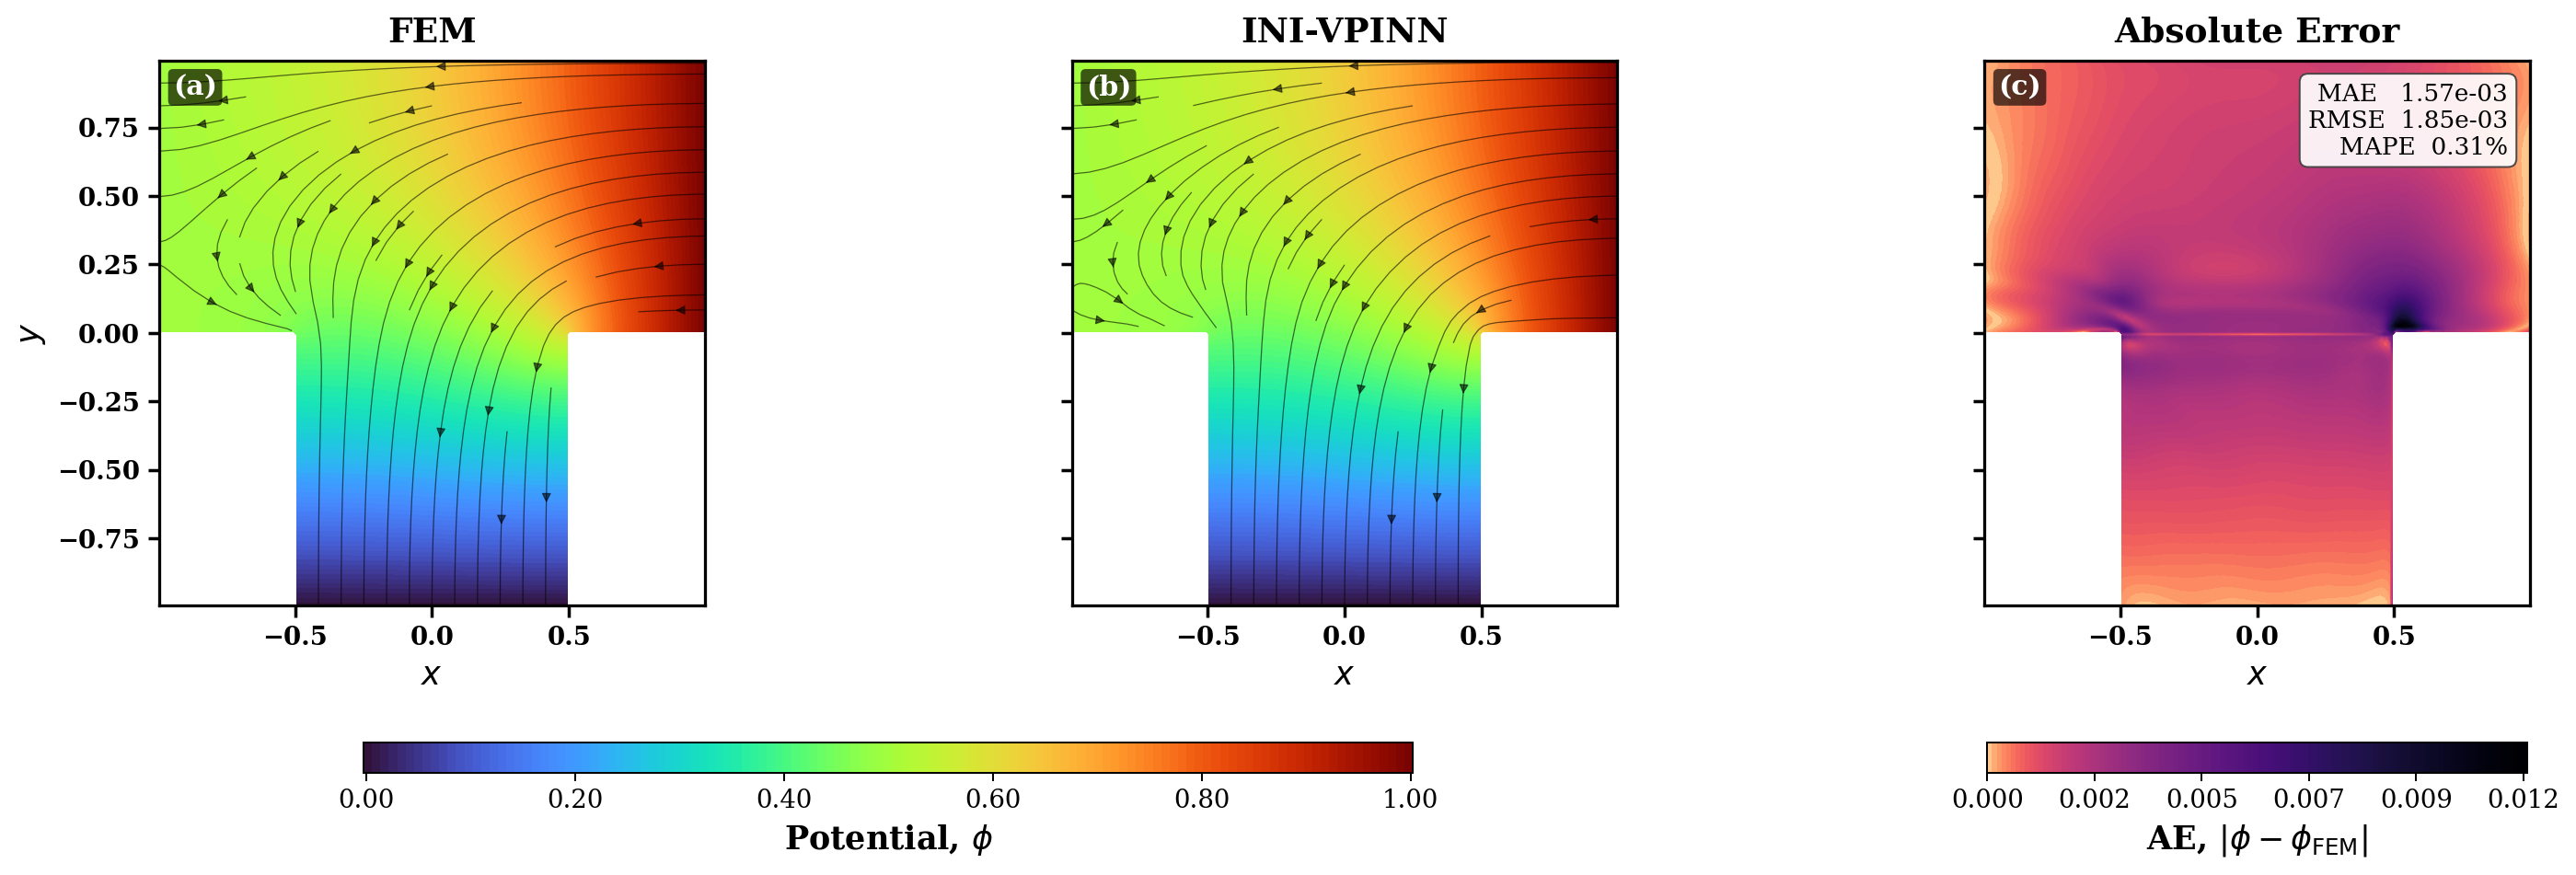

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import matplotlib.colors as mcolors
from matplotlib.ticker import FormatStrFormatter

# ==============================
# CONFIG
# ==============================
FEM_FILE = "V_T_200.txt"
IMPL_FILE = "INIVPINN_TD.txt"
SKIPROWS_PRED = 1
DELTA = 0.01
USE_FEM_RANGE = True
SAVE_FIG = True
OUT_BASENAME = "Tshape_FEM_INI_Homogeneous"

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 180,
})

# ==============================
# HELPERS
# ==============================
def style_axes(ax):
    ax.tick_params(axis="both", which="both", width=1.4, length=5)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")
    for side in ["left", "bottom", "top", "right"]:
        ax.spines[side].set_linewidth(1.3)

def safe_mean(a):
    return np.nan if not np.isfinite(a).any() else np.nanmean(a)

def robust_minmax(A):
    vmin, vmax = np.nanmin(A), np.nanmax(A)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        eps = 1e-12 if vmax == 0 else 1e-3 * abs(vmax)
        vmin, vmax = vmax - eps, vmax + eps
    return vmin, vmax

def region_interpolate(x, y, z, Xg, Yg, region_mask):
    """
    Interpolate source points onto one target region of the T-domain.

    x, y, z are already filtered to the desired physical region.
    region_mask applies only to the target grid.
    """
    src_points = np.column_stack((x, y))
    tgt_points = np.column_stack((Xg[region_mask], Yg[region_mask]))

    out = griddata(src_points, z, tgt_points, method="linear")

    missing = ~np.isfinite(out)
    if np.any(missing):
        out[missing] = griddata(
            src_points,
            z,
            tgt_points[missing],
            method="nearest",
        )

    return out

def interp_t_domain_by_regions(x, y, z, Xg, Yg):
    """
    Interpolate on the T-domain using two separate connected regions:
      1) upper bar: y >= 0
      2) lower stem: -0.5 <= x <= 0.5 and y < 0

    This avoids cubic interpolation artefacts across the missing corners.
    """
    U = np.full_like(Xg, np.nan, dtype=float)

    upper_src = y >= 0.0
    upper_tgt = Yg >= 0.0
    if np.any(upper_src) and np.any(upper_tgt):
        U[upper_tgt] = region_interpolate(
            x[upper_src], y[upper_src], z[upper_src], Xg, Yg, upper_tgt
        )

    stem_src = (y < 0.0) & (x >= -0.5) & (x <= 0.5)
    stem_tgt = (Yg < 0.0) & (Xg >= -0.5) & (Xg <= 0.5)
    if np.any(stem_src) and np.any(stem_tgt):
        U[stem_tgt] = region_interpolate(
            x[stem_src], y[stem_src], z[stem_src], Xg, Yg, stem_tgt
        )

    return U

def try_reshape_structured(x, y, u, xtest, ytest, tol=1e-12):
    """
    If the prediction file is already on the same structured grid as (xtest, ytest),
    reshape directly instead of interpolating.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    u = np.asarray(u, dtype=float)

    ux = np.unique(np.round(x, 12))
    uy = np.unique(np.round(y, 12))

    if len(ux) != len(xtest) or len(uy) != len(ytest):
        return None
    if not np.allclose(ux, xtest, atol=tol, rtol=0.0):
        return None
    if not np.allclose(uy, ytest, atol=tol, rtol=0.0):
        return None
    if len(x) != len(xtest) * len(ytest):
        return None

    order = np.lexsort((x, y))
    x_sorted = x[order]
    y_sorted = y[order]
    u_sorted = u[order]

    Xref, Yref = np.meshgrid(xtest, ytest)
    if not np.allclose(x_sorted.reshape(len(ytest), len(xtest)), Xref, atol=tol, rtol=0.0):
        return None
    if not np.allclose(y_sorted.reshape(len(ytest), len(xtest)), Yref, atol=tol, rtol=0.0):
        return None

    return u_sorted.reshape(len(ytest), len(xtest))

def fill_nan_nearest(U, Xg, Yg):
    """
    Fill NaNs by nearest valid values only for gradient computation.
    This is better than filling with the global mean.
    """
    U = np.asarray(U, dtype=float)
    valid = np.isfinite(U)
    if np.all(valid):
        return U.copy()

    points_valid = np.column_stack((Xg[valid], Yg[valid]))
    values_valid = U[valid]
    points_nan = np.column_stack((Xg[~valid], Yg[~valid]))

    U_filled = U.copy()
    U_filled[~valid] = griddata(points_valid, values_valid, points_nan, method="nearest")
    return U_filled

def potential_to_field(U, Xg, Yg, dx, dy):
    """
    Convert potential into field lines with a safer fill strategy for gradients.
    """
    U_work = fill_nan_nearest(U, Xg, Yg)
    dUy, dUx = np.gradient(U_work, dy, dx)
    Ex, Ey = -dUx, -dUy
    speed = np.sqrt(Ex**2 + Ey**2)
    smax = np.nanmax(speed) if np.isfinite(speed).any() else 1.0
    lw = np.clip(0.7 + 1.6 * speed / smax, 0.7, 2.3)

    mask = np.isfinite(U)
    return np.where(mask, Ex, np.nan), np.where(mask, Ey, np.nan), np.where(mask, lw, np.nan)

# ==============================
# LOAD DATA
# ==============================
fem = np.loadtxt(FEM_FILE)
x_f, y_f, u_f = fem[:, 0], fem[:, 1], fem[:, 2]

impl = np.loadtxt(IMPL_FILE, skiprows=SKIPROWS_PRED)
x_i, y_i, u_i = impl[:, 0], impl[:, 1], impl[:, 2]

# ==============================
# COMMON GRID
# ==============================
valid_fem = np.isfinite(u_f)
xmin, xmax = np.nanmin(x_f[valid_fem]), np.nanmax(x_f[valid_fem])
ymin, ymax = np.nanmin(y_f[valid_fem]), np.nanmax(y_f[valid_fem])

xtest = np.arange(xmin, xmax + DELTA, DELTA)
ytest = np.arange(ymin, ymax + DELTA, DELTA)
Xg, Yg = np.meshgrid(xtest, ytest)

mask_T = (Yg >= 0.0) | ((Xg >= -0.5) & (Xg <= 0.5) & (Yg < 0.0))

# ==============================
# GRIDDED FIELDS
# ==============================
# FEM: interpolate by connected T-domain regions.
U_fem_grid = interp_t_domain_by_regions(
    x_f[valid_fem], y_f[valid_fem], u_f[valid_fem], Xg, Yg
)

# INI-VPINN: reshape directly if already structured; otherwise interpolate by regions.
U_impl_grid = try_reshape_structured(x_i, y_i, u_i, xtest, ytest)
if U_impl_grid is None:
    U_impl_grid = interp_t_domain_by_regions(x_i, y_i, u_i, Xg, Yg)

U_fem_plot = np.where(mask_T, U_fem_grid, np.nan)
U_impl_plot = np.where(mask_T, U_impl_grid, np.nan)

# ==============================
# ERROR METRICS
# ==============================
ok = np.isfinite(U_fem_plot) & np.isfinite(U_impl_plot)
ERR_impl = np.full_like(U_fem_plot, np.nan)
ERR_impl[ok] = np.abs(U_impl_plot[ok] - U_fem_plot[ok])

mae_impl = safe_mean(ERR_impl)
rmse_impl = np.sqrt(safe_mean(ERR_impl**2))
avg_abs_fem = safe_mean(np.abs(U_fem_plot))
mape_impl = safe_mean((ERR_impl / avg_abs_fem) * 100.0) if avg_abs_fem > 0 else np.nan

# ==============================
# COLORMAPS & NORMALIZATION
# ==============================
if USE_FEM_RANGE:
    umin, umax = robust_minmax(U_fem_plot)
else:
    umin, umax = robust_minmax(np.stack([U_fem_plot, U_impl_plot], axis=0))

_, evmax = robust_minmax(ERR_impl)

# Vivid but readable colormaps.
cmap_main = plt.get_cmap("turbo").copy()
cmap_main.set_bad("white")

cmap_err = plt.get_cmap("magma_r").copy()
cmap_err.set_bad("white")

norm_u = mcolors.Normalize(vmin=umin, vmax=umax, clip=True)
norm_err = mcolors.PowerNorm(gamma=0.40, vmin=0.0, vmax=evmax, clip=True)

# ==============================
# STREAMLINES
# ==============================
dx, dy = xtest[1] - xtest[0], ytest[1] - ytest[0]
Ex_f, Ey_f, lw_f = potential_to_field(U_fem_plot, Xg, Yg, dx, dy)
Ex_i, Ey_i, lw_i = potential_to_field(U_impl_plot, Xg, Yg, dx, dy)

# ==============================
# 1 x 3 PUBLICATION FIGURE
# ==============================
fig, axs = plt.subplots(
    1, 3, figsize=(16.5, 5.2),
    sharex=True, sharey=True,
    constrained_layout=True
)

solution_data = [
    (axs[0], U_fem_plot, Ex_f, Ey_f, lw_f, "FEM"),
    (axs[1], U_impl_plot, Ex_i, Ey_i, lw_i, "INI-VPINN"),
]

ims = []
for ax, U, Ex, Ey, lw, title in solution_data:
    im = ax.contourf(Xg, Yg, U, levels=140, cmap=cmap_main, norm=norm_u)
    ims.append(im)
    ax.streamplot(
        Xg, Yg, Ex, Ey,
        density=0.85,
        linewidth=np.clip(0.70 * lw, 0.50, 1.30),
        arrowsize=0.85,
        color=(0, 0, 0, 0.58),
    )
    ax.set_title(title, pad=8)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x$")
    style_axes(ax)

errim = axs[2].contourf(
    Xg, Yg, ERR_impl,
    levels=140,
    cmap=cmap_err,
    norm=norm_err,
)
axs[2].set_title("Absolute Error", pad=8)
axs[2].set_aspect("equal")
axs[2].set_xlabel(r"$x$")
style_axes(axs[2])

axs[0].set_ylabel(r"$y$")
for ax in axs:
    ax.set_xlim(xtest.min(), xtest.max())
    ax.set_ylim(ytest.min(), ytest.max())

metric_text = (
    f"MAE   {mae_impl:.2e}\n"
    f"RMSE  {rmse_impl:.2e}\n"
    f"MAPE  {mape_impl:.2f}%"
)
axs[2].text(
    0.96, 0.96, metric_text,
    transform=axs[2].transAxes,
    ha="right", va="top",
    fontsize=10.5,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="0.25",
        linewidth=0.8,
        alpha=0.92,
    ),
    zorder=10,
)

for lab, ax in zip(["(a)", "(b)", "(c)"], axs):
    ax.text(
        0.025, 0.975, lab,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=12, fontweight="bold",
        color="white",
        bbox=dict(
            boxstyle="round,pad=0.18",
            facecolor="black",
            edgecolor="none",
            alpha=0.65,
        ),
        zorder=12,
    )

# Shared colorbar for FEM + INI-VPINN.
cbar_u = fig.colorbar(
    ims[0], ax=axs[:2],
    orientation="horizontal",
    fraction=0.055, pad=0.09, aspect=35,
)
cbar_u.set_label(r"Potential, $\phi$", fontweight="bold")
cbar_u.ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
cbar_u.set_ticks(np.linspace(umin, umax, 6))

# Separate, cleaner error colorbar.
cbar_e = fig.colorbar(
    errim, ax=axs[2],
    orientation="horizontal",
    fraction=0.055, pad=0.09, aspect=18,
)
cbar_e.set_label(r"AE, $|\phi-\phi_{\mathrm{FEM}}|$", fontweight="bold")
cbar_e.ax.xaxis.set_major_formatter(FormatStrFormatter("%.3f"))
cbar_e.set_ticks(np.linspace(0.0, evmax, 6))

if SAVE_FIG:
    for ext in ("png", "pdf"):
        plt.savefig(f"{OUT_BASENAME}.{ext}", bbox_inches="tight", dpi=600)

plt.show()


# Error History Plot

This script reads the saved INI-VPINN training history and plots relative \(L_2\) error against:

- wall-clock training time;
- training epochs/iterations.

## Required file

```text
INI_ERROR_VS_WALLTIME.npz
```

## Main settings

```python
DATA_DIR = "."
SAVE_FIGURE = True
OUTPUT_FIGURE = "ERROR_VS_WALLTIME_AND_EPOCHS_INI.png"
DPI = 300
```

Change `DATA_DIR` if the `.npz` file is stored elsewhere.

## Figure

The script produces a `1 x 2` figure:

```text
(a) Relative L2 error vs wall-clock time
(b) Relative L2 error vs training epochs
```

Both panels use a logarithmic y-axis.

## Output

If

```python
SAVE_FIGURE = True
```
the figure is saved as:

```text
ERROR_VS_WALLTIME_AND_EPOCHS_INI.png
```



Loaded histories
INI-VPINN :   18 points | final epoch=80001 | final time=379.654 s | final rel L2=2.024058e-03 | N_quad=7

Saved figure: ./ERROR_VS_WALLTIME_AND_EPOCHS_INI.png


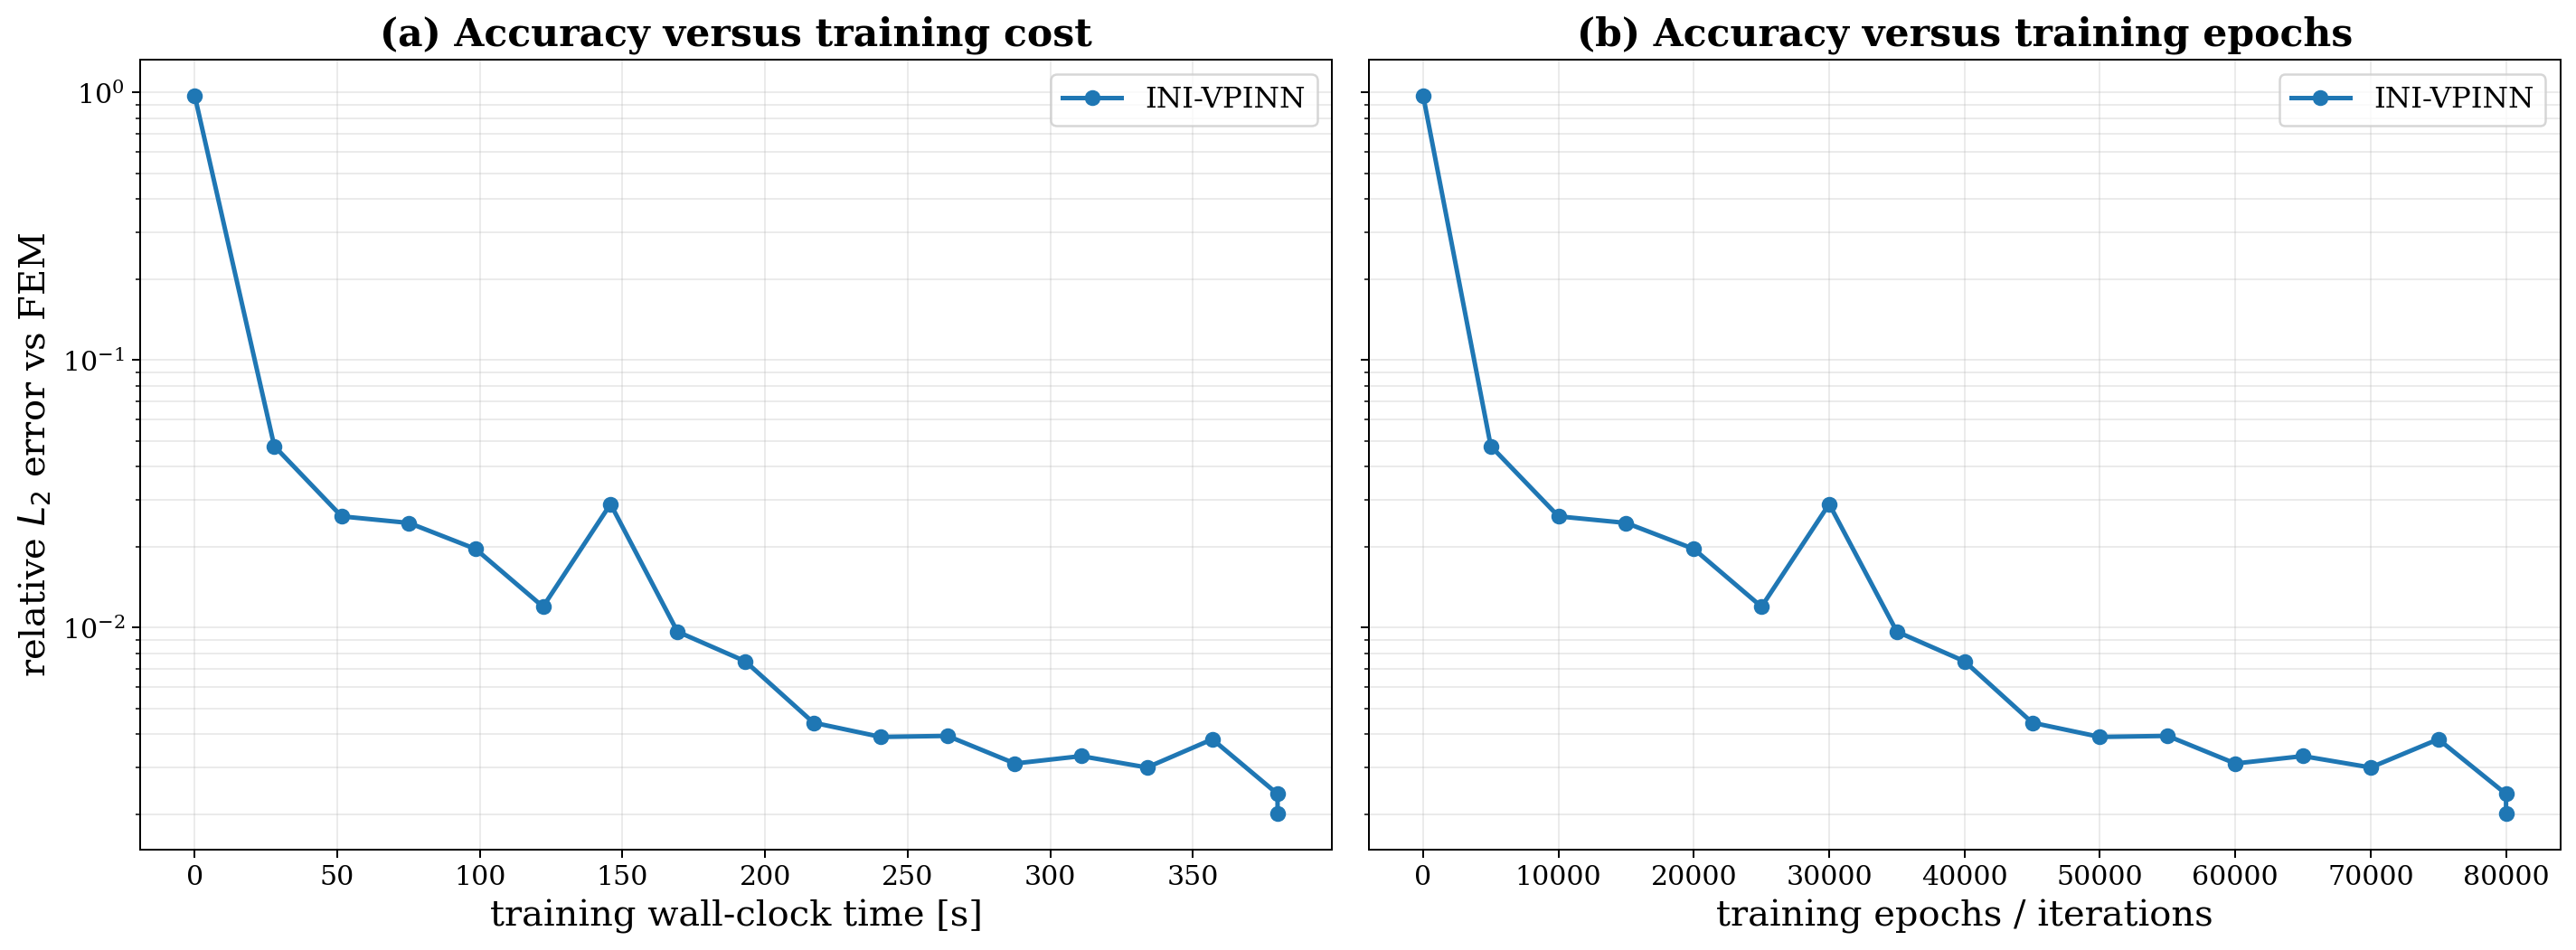

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "."
SAVE_FIGURE = True
OUTPUT_FIGURE = "ERROR_VS_WALLTIME_AND_EPOCHS_INI.png"
DPI = 300

FILES = {
    "INI-VPINN": "INI_ERROR_VS_WALLTIME.npz",
}

def load_history(filename):
    path = os.path.join(DATA_DIR, filename)

    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find: {path}")

    with np.load(path, allow_pickle=False) as d:
        required = ["times", "errors", "iterations"]
        missing = [key for key in required if key not in d.files]

        if missing:
            raise KeyError(
                f"{filename}: missing keys {missing}\n"
                f"Available keys: {d.files}"
            )

        times = np.asarray(d["times"], dtype=float).reshape(-1)
        errors = np.asarray(d["errors"], dtype=float).reshape(-1)
        iterations = np.asarray(d["iterations"], dtype=float).reshape(-1)

        n_quad = None
        if "n_quad" in d.files:
            n_quad = int(np.asarray(d["n_quad"]).reshape(-1)[0])

    if not (len(times) == len(errors) == len(iterations)):
        raise ValueError(
            f"{filename}: inconsistent lengths: "
            f"times={len(times)}, errors={len(errors)}, "
            f"iterations={len(iterations)}"
        )

    good = (
        np.isfinite(times)
        & np.isfinite(errors)
        & np.isfinite(iterations)
        & (errors > 0.0)
    )

    times = times[good]
    errors = errors[good]
    iterations = iterations[good]

    order = np.argsort(iterations)

    return {
        "times": times[order],
        "errors": errors[order],
        "iterations": iterations[order],
        "n_quad": n_quad,
    }

# Load hp, INI, and UV histories
histories = {}
for label, filename in FILES.items():
    histories[label] = load_history(filename)

# Print summary
print("\nLoaded histories")
for label, h in histories.items():
    qtxt = f" | N_quad={h['n_quad']}" if h["n_quad"] is not None else ""
    print(
        f"{label:10s}: {len(h['errors']):4d} points"
        f" | final epoch={h['iterations'][-1]:.0f}"
        f" | final time={h['times'][-1]:.3f} s"
        f" | final rel L2={h['errors'][-1]:.6e}"
        f"{qtxt}"
    )

# 1 x 2 figure
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(16, 6),
    sharey=True
)

# (a) Relative L2 error vs wall-clock time
for label, h in histories.items():
    ax1.plot(
        h["times"],
        h["errors"],
        "-o",
        linewidth=2.0,
        markersize=6,
        label=label,
    )

ax1.set_yscale("log")
ax1.set_xlabel("training wall-clock time [s]", fontsize=16)
ax1.set_ylabel(r"relative $L_2$ error vs FEM", fontsize=16)
ax1.set_title(
    "(a) Accuracy versus training cost",
    fontsize=17,
    fontweight="bold",
)
ax1.tick_params(axis="both", which="major", labelsize=12)
ax1.tick_params(axis="both", which="minor", labelsize=10)
ax1.grid(True, which="both", alpha=0.25)
ax1.legend(fontsize=13, frameon=True)

# (b) Relative L2 error vs epochs
for label, h in histories.items():
    ax2.plot(
        h["iterations"],
        h["errors"],
        "-o",
        linewidth=2.0,
        markersize=6,
        label=label,
    )

ax2.set_yscale("log")
ax2.set_xlabel("training epochs / iterations", fontsize=16)
ax2.set_title(
    "(b) Accuracy versus training epochs",
    fontsize=17,
    fontweight="bold",
)
ax2.tick_params(axis="both", which="major", labelsize=12)
ax2.tick_params(axis="both", which="minor", labelsize=10)
ax2.grid(True, which="both", alpha=0.25)
ax2.legend(fontsize=13, frameon=True)

fig.tight_layout()

if SAVE_FIGURE:
    out = os.path.join(DATA_DIR, OUTPUT_FIGURE)
    fig.savefig(out, dpi=DPI, bbox_inches="tight")
    print("\nSaved figure:", out)

plt.show()